In [1]:
import polars as pl
import pandas as pd
import json 
from pycomorb import comorbidity
import icu_flag
import hosps
import cim10_utils
import comorbidity_utils
import drug
import patient_utils

In [2]:
unit_mapping = pl.read_parquet("unit_mapping.parquet")
stay = pl.read_parquet("stay.parquet")
document_data = pl.read_parquet("document_data.parquet")
treatments = pl.read_parquet("traitement.parquet")
patient = pl.read_parquet("patient.parquet")

In [3]:
unit_mapping_icu = icu_flag.add_icu_unit_flag(unit_mapping)

In [4]:
stay_with_icu = icu_flag.add_icu_flag_to_stay(stay, unit_mapping_icu)

In [5]:
pl.Config.set_tbl_rows(-1)
stay_with_icu

patient_id,centre,hosp_id,hosp_admission_datetime,hosp_discharge_datetime,stay_id,unit_code,unit_admission_datetime,unit_discharge_datetime,inclusion_flag,unit_name,unit_group,icu_unit_flag
str,str,i64,datetime[μs],datetime[μs],i64,str,datetime[μs],datetime[μs],i64,str,str,i8
"""P001""","""angers""",1001,2015-03-10 09:30:00,2015-03-16 14:00:00,1,"""101""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,"""Cardiologie Angers""","""Cardiologie""",0
"""P001""","""angers""",1002,2018-07-04 11:15:00,2018-07-12 10:00:00,2,"""102""",2018-07-04 11:15:00,2018-07-05 10:00:00,1,"""Urgences Angers""","""Urgences""",0
"""P001""","""angers""",1002,2018-07-04 11:15:00,2018-07-12 10:00:00,3,"""103""",2018-07-05 10:00:00,2018-07-12 10:00:00,1,"""Pneumologie Angers""","""Pneumologie""",0
"""P002""","""brest""",2001,2014-06-22 08:40:00,2014-06-28 15:30:00,4,"""104""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,"""Médecine interne Brest""","""Médecine interne""",0
"""P002""","""brest""",2002,2019-01-18 13:20:00,2019-01-25 11:00:00,5,"""103""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,"""Pneumologie Brest""","""Pneumologie""",0
"""P003""","""nantes""",3001,2016-02-05 10:00:00,2016-02-11 16:00:00,6,"""101""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,"""Cardiologie Nantes""","""Cardiologie""",0
"""P003""","""nantes""",3002,2019-04-09 09:15:00,2019-04-18 10:30:00,7,"""103""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,"""Pneumologie Nantes""","""Pneumologie""",0
"""P003""","""nantes""",3003,2020-10-02 12:00:00,2020-10-09 09:45:00,8,"""102""",2020-10-02 12:00:00,2020-10-03 09:30:00,1,"""Urgences Nantes""","""Urgences""",0
"""P003""","""nantes""",3003,2020-10-02 12:00:00,2020-10-09 09:45:00,9,"""104""",2020-10-03 09:30:00,2020-10-09 09:45:00,1,"""Médecine interne Nantes""","""Médecine interne""",0


In [6]:
hosp = hosps.get_hosp(stay_with_icu)

In [7]:
stay_with_icu.shape

(24, 13)

In [8]:
hosp.shape

(20, 7)

In [9]:
hosp.head()

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0


In [10]:
pl.Config.set_tbl_rows(-1)
hosp

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0
"""P003""",3003,"""nantes""",2020-10-02 12:00:00,2020-10-09 09:45:00,1,0
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1


In [11]:
inclusion_hosps = hosps.get_inclusion_hosps(hosp)

In [12]:
pl.Config.set_tbl_rows(-1)
inclusion_hosps

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0
"""P003""",3003,"""nantes""",2020-10-02 12:00:00,2020-10-09 09:45:00,1,0
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1


In [13]:
first_inclusion_hosps = hosps.get_first_inclusion_hosps(inclusion_hosps)

In [14]:
pl.Config.set_tbl_rows(-1)
first_inclusion_hosps

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0


In [15]:
preceding_hosps = hosps.get_preceding_hosps(hosp)

In [16]:
pl.Config.set_tbl_rows(-1)
preceding_hosps

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0
"""P006""",6001,"""brest""",2017-05-06 09:20:00,2017-05-12 11:30:00,0,0
"""P008""",8001,"""tours""",2017-09-10 13:00:00,2017-09-16 09:30:00,0,0
"""P009""",9001,"""angers""",2014-12-03 10:15:00,2014-12-09 14:20:00,0,0
"""P010""",10001,"""brest""",2015-04-18 12:20:00,2015-04-23 10:00:00,0,0


In [17]:
included_patients = hosps.get_included_patients(first_inclusion_hosps)

In [18]:
included_patients

patient_id
str
"""P001"""
"""P002"""
"""P003"""
"""P004"""
"""P005"""
"""P006"""
"""P007"""
"""P008"""
"""P009"""


In [19]:
preceding_hosps_of_included_patients = hosps.get_preceding_hosps_of_included_patients(preceding_hosps, included_patients)

In [20]:
pl.Config.set_tbl_rows(-1)
preceding_hosps_of_included_patients

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0
"""P006""",6001,"""brest""",2017-05-06 09:20:00,2017-05-12 11:30:00,0,0
"""P008""",8001,"""tours""",2017-09-10 13:00:00,2017-09-16 09:30:00,0,0
"""P009""",9001,"""angers""",2014-12-03 10:15:00,2014-12-09 14:20:00,0,0
"""P010""",10001,"""brest""",2015-04-18 12:20:00,2015-04-23 10:00:00,0,0


In [21]:
pl.Config.set_tbl_rows(-1)
document_data

patient_id,centre,hosp_id,stay_id,document_data_id,terminology_code,concept_code,concept_name,datetime,numeric_value,text_value,unit
str,str,i64,i64,i64,str,str,str,datetime[μs],f64,str,str
"""P001""","""angers""",1001,1,1,"""CIM-10""","""I25""","""Cardiopathie ischémique chroni…",2015-03-12 10:20:00,null,"""DA""",null
"""P001""","""angers""",1001,1,2,"""CIM-10""","""I48""","""Fibrillation et flutter auricu…",2015-03-12 10:25:00,null,"""DA""",null
"""P001""","""angers""",1002,3,3,"""CIM-10""","""J960""","""Insuffisance respiratoire aigu…",2018-07-05 11:10:00,null,"""DP""",null
"""P002""","""brest""",2001,4,4,"""CIM-10""","""E119""","""Diabète sucré de type 2 sans c…",2014-06-23 09:30:00,null,"""DA""",null
"""P002""","""brest""",2002,5,5,"""CIM-10""","""J960""","""Insuffisance respiratoire aigu…",2019-01-19 10:15:00,null,"""DP""",null
"""P003""","""nantes""",3001,6,6,"""CIM-10""","""I50""","""Insuffisance cardiaque""",2016-02-06 14:00:00,null,"""DA""",null
"""P003""","""nantes""",3001,6,7,"""CIM-10""","""N18""","""Insuffisance rénale chronique""",2016-02-06 14:10:00,null,"""DA""",null
"""P003""","""nantes""",3002,7,8,"""CIM-10""","""J960""","""Insuffisance respiratoire aigu…",2019-04-10 08:45:00,null,"""DP""",null
"""P004""","""tours""",4001,10,9,"""CIM-10""","""I21""","""Infarctus aigu du myocarde""",2015-11-15 16:30:00,null,"""DA""",null


In [22]:
document_data = document_data.with_columns(
    pl.when(pl.col("terminology_code") == "CIM-10")
    .then(pl.lit("cim10"))
    .otherwise(pl.col("terminology_code"))
    .alias("terminology_code")
)

In [23]:
cim10 = cim10_utils.load_cim10(document_data)

In [24]:
pl.Config.set_tbl_rows(-1)
cim10.sort(pl.col("patient_id"))

patient_id,hosp_id,concept_code,centre
str,i64,str,str
"""P001""",1002,"""J960""","""angers"""
"""P001""",1001,"""I48""","""angers"""
"""P001""",1001,"""I25""","""angers"""
"""P002""",2001,"""E119""","""brest"""
"""P002""",2002,"""J960""","""brest"""
"""P003""",3001,"""N18""","""nantes"""
"""P003""",3001,"""I50""","""nantes"""
"""P003""",3002,"""J960""","""nantes"""
"""P004""",4002,"""Z950""","""tours"""


In [25]:
preceding_hosps_of_included_patients

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0
"""P006""",6001,"""brest""",2017-05-06 09:20:00,2017-05-12 11:30:00,0,0
"""P008""",8001,"""tours""",2017-09-10 13:00:00,2017-09-16 09:30:00,0,0
"""P009""",9001,"""angers""",2014-12-03 10:15:00,2014-12-09 14:20:00,0,0
"""P010""",10001,"""brest""",2015-04-18 12:20:00,2015-04-23 10:00:00,0,0


In [26]:
preceding_hosps_of_included_patients_with_cim10 = cim10_utils.get_preceding_hosps_of_included_patients_with_cim10(preceding_hosps_of_included_patients, cim10)

In [27]:
pl.Config.set_tbl_rows(-1)
preceding_hosps_of_included_patients_with_cim10

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,concept_code
str,i64,str,datetime[μs],datetime[μs],i64,i8,str
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0,"""I48"""
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0,"""I25"""
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0,"""E119"""
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0,"""N18"""
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0,"""I50"""
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0,"""I21"""
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0,"""E785"""
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0,"""C349"""
"""P006""",6001,"""brest""",2017-05-06 09:20:00,2017-05-12 11:30:00,0,0,null


In [28]:
disease_dict = comorbidity_utils.load_disease_dict('cim10_nancy.json')

In [29]:
comorbidities = comorbidity_utils.get_comorbidities(
    preceding_hosps_of_included_patients_with_cim10,
    disease_dict
)

In [30]:
comorbidities.sort("patient_id")

patient_id,hosp_id,centre,inclusion_flag,hosp_admission_datetime,hosp_discharge_datetime,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète
str,i64,str,i64,datetime[μs],datetime[μs],i8,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P001""",1001,"""angers""",0,2015-03-10 09:30:00,2015-03-16 14:00:00,0,1,1,0,0,0,0,0,0,0,0,0,0
"""P002""",2001,"""brest""",0,2014-06-22 08:40:00,2014-06-28 15:30:00,0,0,0,0,0,0,0,0,0,0,0,0,1
"""P003""",3001,"""nantes""",0,2016-02-05 10:00:00,2016-02-11 16:00:00,0,0,0,1,0,0,1,0,0,0,0,0,0
"""P004""",4001,"""tours""",0,2015-11-14 15:00:00,2015-11-20 13:00:00,0,1,0,0,0,0,0,0,0,0,0,0,0
"""P005""",5001,"""angers""",0,2016-08-19 11:00:00,2016-08-24 10:00:00,0,0,0,0,0,0,0,0,0,1,0,1,0
"""P006""",6001,"""brest""",0,2017-05-06 09:20:00,2017-05-12 11:30:00,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P008""",8001,"""tours""",0,2017-09-10 13:00:00,2017-09-16 09:30:00,0,0,0,0,0,0,0,1,0,0,0,0,0
"""P009""",9001,"""angers""",0,2014-12-03 10:15:00,2014-12-09 14:20:00,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P010""",10001,"""brest""",0,2015-04-18 12:20:00,2015-04-23 10:00:00,0,0,1,0,0,0,0,0,0,0,0,0,0


In [31]:
patient_comorbidities = comorbidity_utils.get_patient_comorbidities(comorbidities)

In [32]:
patient_comorbidities.sort("patient_id")

patient_id,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète
str,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""P001""",1,1,0,0,0,0,0,0,0,0,0,0
"""P002""",0,0,0,0,0,0,0,0,0,0,0,1
"""P003""",0,0,1,0,0,1,0,0,0,0,0,0
"""P004""",1,0,0,0,0,0,0,0,0,0,0,0
"""P005""",0,0,0,0,0,0,0,0,1,0,1,0
"""P006""",0,0,0,0,0,0,0,0,0,0,0,0
"""P008""",0,0,0,0,0,0,1,0,0,0,0,0
"""P009""",0,0,0,0,0,0,0,0,0,0,0,0
"""P010""",0,1,0,0,0,0,0,0,0,0,0,0


In [33]:
disease_cols = ["Cardiopathie ischémique", "Fibrillation atriale", "Insuffisance cardiaque chronique",
               "Pacemaker", "Pontage aorto-coronarien", "Insuffisance rénale chronique", "Antécédent d'AVC",
               "Cirrhose", "Cancer actif", "Immunodépression", "Dyslipidémie", "Diabète"]


In [34]:
included_patients_with_comorbidity =comorbidity_utils.get_included_patients_with_comorbidity(
    first_inclusion_hosps,
    patient_comorbidities,
    disease_cols
)

In [35]:
pl.Config.set_tbl_rows(-1)

included_patients_with_comorbidity

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1,0,0,0,0,0,0,1,0,0,0,0,0
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [36]:
treatments

ent_id,context_id,text_id,patient_id,context_type,ent_name,code_atc,code_ucd,dose,frequency,ent_start,ent_end
str,str,str,str,str,str,str,str,list[str],list[str],i64,i64
"""D001""","""1001""","""TXT001""","""P001""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""2.5 mg""]","[""1 fois/jour""]",20150310,20150316
"""D002""","""1001""","""TXT001""","""P001""","""hospitalisation""","""ramipril""","""C09AA05""","""UCD002""","[""5 mg""]","[""1 fois/jour""]",20150310,20150316
"""D003""","""2001""","""TXT002""","""P002""","""hospitalisation""","""metformine""","""A10BA02""","""UCD003""","[""500 mg""]","[""2 fois/jour""]",20140622,20140628
"""D004""","""3001""","""TXT003""","""P003""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""1.25 mg""]","[""1 fois/jour""]",20160205,20160211
"""D005""","""3001""","""TXT003""","""P003""","""hospitalisation""","""furosémide""","""C03CA01""","""UCD004""","[""40 mg""]","[""1 fois/jour""]",20160205,20160211
"""D006""","""3001""","""TXT003""","""P003""","""hospitalisation""","""spironolactone""","""C03DA01""","""UCD005""","[""25 mg""]","[""1 fois/jour""]",20160205,20160211
"""D007""","""4001""","""TXT004""","""P004""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""2.5 mg""]","[""1 fois/jour""]",20151114,20151120
"""D008""","""4002""","""TXT005""","""P004""","""hospitalisation""","""sacubitril valsartan""","""C09DX04""","""UCD006""","[""24/26 mg""]","[""2 fois/jour""]",20180303,20180318
"""D009""","""4002""","""TXT005""","""P004""","""hospitalisation""","""dapagliflozine""","""A10BK01""","""UCD007""","[""10 mg""]","[""1 fois/jour""]",20180303,20180318


In [37]:
treatments = treatments.rename({
    "frequency": "frequency/duration"
})

In [38]:
treatments

ent_id,context_id,text_id,patient_id,context_type,ent_name,code_atc,code_ucd,dose,frequency/duration,ent_start,ent_end
str,str,str,str,str,str,str,str,list[str],list[str],i64,i64
"""D001""","""1001""","""TXT001""","""P001""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""2.5 mg""]","[""1 fois/jour""]",20150310,20150316
"""D002""","""1001""","""TXT001""","""P001""","""hospitalisation""","""ramipril""","""C09AA05""","""UCD002""","[""5 mg""]","[""1 fois/jour""]",20150310,20150316
"""D003""","""2001""","""TXT002""","""P002""","""hospitalisation""","""metformine""","""A10BA02""","""UCD003""","[""500 mg""]","[""2 fois/jour""]",20140622,20140628
"""D004""","""3001""","""TXT003""","""P003""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""1.25 mg""]","[""1 fois/jour""]",20160205,20160211
"""D005""","""3001""","""TXT003""","""P003""","""hospitalisation""","""furosémide""","""C03CA01""","""UCD004""","[""40 mg""]","[""1 fois/jour""]",20160205,20160211
"""D006""","""3001""","""TXT003""","""P003""","""hospitalisation""","""spironolactone""","""C03DA01""","""UCD005""","[""25 mg""]","[""1 fois/jour""]",20160205,20160211
"""D007""","""4001""","""TXT004""","""P004""","""hospitalisation""","""bisoprolol""","""C07AB07""","""UCD001""","[""2.5 mg""]","[""1 fois/jour""]",20151114,20151120
"""D008""","""4002""","""TXT005""","""P004""","""hospitalisation""","""sacubitril valsartan""","""C09DX04""","""UCD006""","[""24/26 mg""]","[""2 fois/jour""]",20180303,20180318
"""D009""","""4002""","""TXT005""","""P004""","""hospitalisation""","""dapagliflozine""","""A10BK01""","""UCD007""","[""10 mg""]","[""1 fois/jour""]",20180303,20180318


In [39]:
treatments_with_flags = drug.create_treatment_flags(treatments)

In [40]:
pl.Config.set_tbl_rows(-1)
treatments_with_flags

patient_id,text_id,ent_name,code_atc,dose,frequency/duration,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide
str,str,str,str,list[str],list[str],i8,i8,i8,i8,i8,i8,i8
"""P001""","""TXT001""","""bisoprolol""","""C07AB07""","[""2.5 mg""]","[""1 fois/jour""]",1,0,0,0,0,0,0
"""P001""","""TXT001""","""ramipril""","""C09AA05""","[""5 mg""]","[""1 fois/jour""]",0,1,0,0,0,0,0
"""P002""","""TXT002""","""metformine""","""A10BA02""","[""500 mg""]","[""2 fois/jour""]",0,0,0,0,0,1,0
"""P003""","""TXT003""","""bisoprolol""","""C07AB07""","[""1.25 mg""]","[""1 fois/jour""]",1,0,0,0,0,0,0
"""P003""","""TXT003""","""furosémide""","""C03CA01""","[""40 mg""]","[""1 fois/jour""]",0,0,0,0,1,0,1
"""P003""","""TXT003""","""spironolactone""","""C03DA01""","[""25 mg""]","[""1 fois/jour""]",0,0,0,0,1,0,0
"""P004""","""TXT004""","""bisoprolol""","""C07AB07""","[""2.5 mg""]","[""1 fois/jour""]",1,0,0,0,0,0,0
"""P004""","""TXT005""","""sacubitril valsartan""","""C09DX04""","[""24/26 mg""]","[""2 fois/jour""]",0,0,0,1,0,0,0
"""P004""","""TXT005""","""dapagliflozine""","""A10BK01""","[""10 mg""]","[""1 fois/jour""]",0,0,0,0,0,1,0


In [41]:
patient_treatment_flags = drug.get_patient_treatment_flags(treatments_with_flags)

In [42]:
pl.Config.set_tbl_rows(-1)
patient_treatment_flags

patient_id,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide
str,i8,i8,i8,i8,i8,i8,i8
"""P001""",1,1,0,0,0,0,0
"""P002""",0,0,0,0,0,1,0
"""P003""",1,0,0,0,1,0,1
"""P004""",1,0,0,1,0,1,0
"""P006""",0,0,0,0,0,0,0
"""P008""",0,0,0,0,0,0,0
"""P010""",0,0,0,0,0,0,0


In [43]:
drug_cols = ["beta_blocker", "ACEI", "ARB", "ARNI", "anti_aldosterone", "sglt2i", "furosemide"]

In [44]:
included_patient_with_comorbidity_drug = drug.get_patient_with_comorbidity_drug(
    included_patients_with_comorbidity,
    patient_treatment_flags,
    drug_cols
)

In [45]:
pl.Config.set_tbl_rows(-1)
included_patient_with_comorbidity_drug

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [46]:
patients_with_death_date = patient_utils.get_patients_with_death_date(patient)

In [47]:
patients_with_death_date

patient_id,gender,birth_date,death_date
str,str,date,date
"""P001""","""F""",1933-04-12,2018-09-21
"""P002""","""M""",1934-11-03,null
"""P003""","""F""",1935-07-26,2020-12-04
"""P004""","""M""",1936-02-18,null
"""P005""","""F""",1937-09-09,2019-03-17
"""P006""","""M""",1938-12-22,null
"""P007""","""F""",1939-05-15,null
"""P008""","""M""",1940-01-30,2021-07-02
"""P009""","""F""",1933-10-05,null


In [48]:
included_patient_with_comorbidity_drug_demo = included_patient_with_comorbidity_drug.join(patients_with_death_date, how = "left", on = "patient_id")

In [49]:
included_patient_with_comorbidity_drug_demo

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide,gender,birth_date,death_date
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,"""F""",1933-04-12,2018-09-21
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,"""M""",1934-11-03,null
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,"""F""",1935-07-26,2020-12-04
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,"""M""",1936-02-18,null
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,"""F""",1937-09-09,2019-03-17
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1938-12-22,null
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1939-05-15,null
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1940-01-30,2021-07-02
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1933-10-05,null


In [50]:
included_patient_with_comorbidity_drug_demo = patient_utils.age_at_admission(included_patient_with_comorbidity_drug_demo)

In [51]:
included_patient_with_comorbidity_drug_demo.select("patient_id", "age_at_admission")

patient_id,age_at_admission
str,i32
"""P001""",85
"""P002""",84
"""P003""",83
"""P004""",82
"""P005""",81
"""P006""",81
"""P007""",81
"""P008""",80
"""P009""",83


In [52]:
preceding_hosps_of_included_patients_with_cim10

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,concept_code
str,i64,str,datetime[μs],datetime[μs],i64,i8,str
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0,"""I48"""
"""P001""",1001,"""angers""",2015-03-10 09:30:00,2015-03-16 14:00:00,0,0,"""I25"""
"""P002""",2001,"""brest""",2014-06-22 08:40:00,2014-06-28 15:30:00,0,0,"""E119"""
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0,"""N18"""
"""P003""",3001,"""nantes""",2016-02-05 10:00:00,2016-02-11 16:00:00,0,0,"""I50"""
"""P004""",4001,"""tours""",2015-11-14 15:00:00,2015-11-20 13:00:00,0,0,"""I21"""
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0,"""E785"""
"""P005""",5001,"""angers""",2016-08-19 11:00:00,2016-08-24 10:00:00,0,0,"""C349"""
"""P006""",6001,"""brest""",2017-05-06 09:20:00,2017-05-12 11:30:00,0,0,null


In [53]:
data_for_score = (
    preceding_hosps_of_included_patients_with_cim10
    .select(["patient_id", "concept_code"])
    .filter(pl.col("concept_code").is_not_null())
    .join(
        included_patient_with_comorbidity_drug_demo
        .select(["patient_id", "age_at_admission"])
        .unique(),
        how="left",
        on="patient_id"
    )
    .unique()
)
data_for_score_pd = data_for_score.to_pandas()

In [54]:
charlson = comorbidity(
    score="charlson",
    df=data_for_score_pd,
    id_col="patient_id",
    code_col="concept_code",
    age_col="age_at_admission",
    implementation="quan",
)

hfrs = comorbidity(
    score="hfrs",
    df=data_for_score_pd,
    id_col="patient_id",
    code_col="concept_code",
    age_col="age_at_admission",
)

In [55]:
hfrs

,patient_id,HFRS Score
0,P002,0.0
1,P010,0.0
2,P008,3.7
3,P003,1.4
4,P004,0.0
5,P001,0.0
6,P005,0.0


In [56]:
charlson_pl = pl.from_pandas(charlson)
hfrs_pl = pl.from_pandas(hfrs)

charlson_selected = charlson_pl.select([
    "patient_id",
    "Charlson Comorbidity Score"
])

hfrs_selected = hfrs_pl.select([
    "patient_id",
    "HFRS Score"
])

final_patient_data = (
    included_patient_with_comorbidity_drug_demo
    .join(charlson_selected, on="patient_id", how="left")
    .join(hfrs_selected, on="patient_id", how="left")
    .with_columns([
        pl.col("Charlson Comorbidity Score").fill_null(0),
        pl.col("HFRS Score").fill_null(0),
    ])
)

In [57]:
final_patient_data

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide,gender,birth_date,death_date,age_at_admission,Charlson Comorbidity Score,HFRS Score
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,i64,f64
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,"""F""",1933-04-12,2018-09-21,85,0,0.0
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,"""M""",1934-11-03,null,84,1,0.0
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,"""F""",1935-07-26,2020-12-04,83,3,1.4
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,"""M""",1936-02-18,null,82,1,0.0
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,"""F""",1937-09-09,2019-03-17,81,2,0.0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1938-12-22,null,81,0,0.0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1939-05-15,null,81,0,0.0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1940-01-30,2021-07-02,80,1,3.7
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1933-10-05,null,83,0,0.0


In [58]:
final_patient_data = final_patient_data.with_columns([
    (
        pl.col("beta_blocker").fill_null(0)
        + pl.max_horizontal([
            pl.col("ACEI").fill_null(0),
            pl.col("ARB").fill_null(0),
            pl.col("ARNI").fill_null(0),
        ])
        + pl.col("anti_aldosterone").fill_null(0)
        + pl.col("sglt2i").fill_null(0)
    ).alias("OMT_component_score")
])

In [59]:
final_patient_data

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,ARNI,anti_aldosterone,sglt2i,furosemide,gender,birth_date,death_date,age_at_admission,Charlson Comorbidity Score,HFRS Score,OMT_component_score
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,i64,f64,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,"""F""",1933-04-12,2018-09-21,85,0,0.0,2
"""P002""",2002,"""brest""",2019-01-18 13:20:00,2019-01-25 11:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,"""M""",1934-11-03,null,84,1,0.0,1
"""P003""",3002,"""nantes""",2019-04-09 09:15:00,2019-04-18 10:30:00,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,"""F""",1935-07-26,2020-12-04,83,3,1.4,2
"""P004""",4002,"""tours""",2018-03-03 07:50:00,2018-03-18 12:20:00,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,"""M""",1936-02-18,null,82,1,0.0,3
"""P005""",5002,"""angers""",2019-02-01 14:10:00,2019-02-08 15:00:00,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,"""F""",1937-09-09,2019-03-17,81,2,0.0,0
"""P006""",6002,"""brest""",2020-06-17 10:45:00,2020-06-24 12:00:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1938-12-22,null,81,0,0.0,0
"""P007""",7001,"""nantes""",2020-07-22 08:30:00,2020-07-29 10:15:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1939-05-15,null,81,0,0.0,0
"""P008""",8002,"""tours""",2020-12-05 06:45:00,2020-12-20 16:00:00,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,"""M""",1940-01-30,2021-07-02,80,1,3.7,0
"""P009""",9002,"""angers""",2017-01-26 09:00:00,2017-02-03 11:45:00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""",1933-10-05,null,83,0,0.0,0


In [60]:
df = final_patient_data

In [64]:
df.schema

Schema([('patient_id', String),
        ('hosp_id', Int64),
        ('centre', String),
        ('hosp_admission_datetime', Datetime(time_unit='us', time_zone=None)),
        ('hosp_discharge_datetime', Datetime(time_unit='us', time_zone=None)),
        ('inclusion_flag', Int64),
        ('icu_stay_flag', Int8),
        ('Cardiopathie ischémique', Int8),
        ('Fibrillation atriale', Int8),
        ('Insuffisance cardiaque chronique', Int8),
        ('Pacemaker', Int8),
        ('Pontage aorto-coronarien', Int8),
        ('Insuffisance rénale chronique', Int8),
        ("Antécédent d'AVC", Int8),
        ('Cirrhose', Int8),
        ('Cancer actif', Int8),
        ('Immunodépression', Int8),
        ('Dyslipidémie', Int8),
        ('Diabète', Int8),
        ('beta_blocker', Int8),
        ('ACEI', Int8),
        ('ARB', Int8),
        ('ARNI', Int8),
        ('anti_aldosterone', Int8),
        ('sglt2i', Int8),
        ('furosemide', Int8),
        ('gender', String),
        ('birth

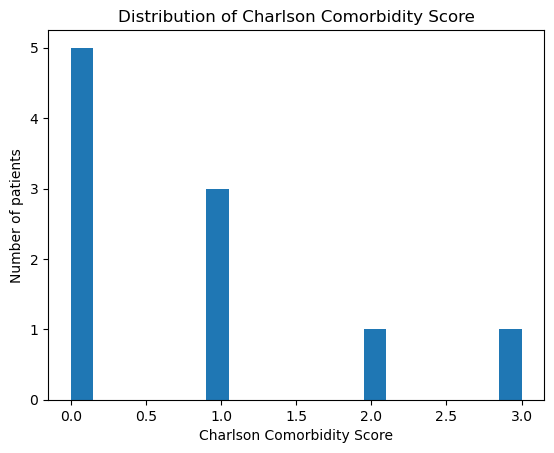

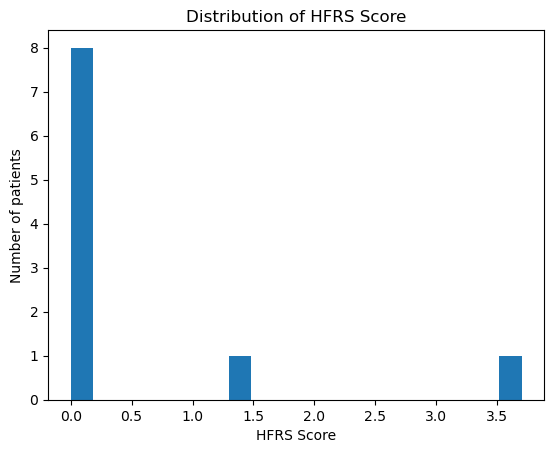

In [65]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["Charlson Comorbidity Score"].to_numpy(), bins=20)
plt.xlabel("Charlson Comorbidity Score")
plt.ylabel("Number of patients")
plt.title("Distribution of Charlson Comorbidity Score")
plt.show()

plt.figure()
plt.hist(df["HFRS Score"].to_numpy(), bins=20)
plt.xlabel("HFRS Score")
plt.ylabel("Number of patients")
plt.title("Distribution of HFRS Score")
plt.show()

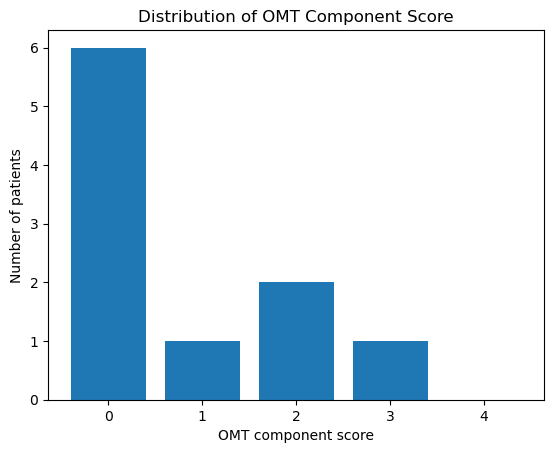

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

score_range = pl.DataFrame({
    "OMT_component_score": [0, 1, 2, 3, 4]
})

omt_counts = (
    df.group_by("OMT_component_score")
    .len()
    .join(score_range, on="OMT_component_score", how="right")
    .with_columns(pl.col("len").fill_null(0))
    .sort("OMT_component_score")
)

x = omt_counts["OMT_component_score"].to_numpy()
y = omt_counts["len"].to_numpy()

plt.figure()
plt.bar(x, y)

plt.xticks([0, 1, 2, 3, 4])
plt.xlabel("OMT component score")
plt.ylabel("Number of patients")
plt.title("Distribution of OMT Component Score")
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

drug_cols = ["beta_blocker", "ACEI", "ARB", "ARNI", "anti_aldosterone", "sglt2i", "furosemide"]
disease_cols = ["Cardiopathie ischémique", "Fibrillation atriale", "Insuffisance cardiaque chronique",
               "Pacemaker", "Pontage aorto-coronarien", "Insuffisance rénale chronique", "Antécédent d'AVC",
               "Cirrhose", "Cancer actif", "Immunodépression", "Dyslipidémie", "Diabète"]

prevelance_matrix = []

for disease in disease_cols:
    # Only patients who have this disease
    patients_with_disease = df.filter(pl.col(disease) == 1)

    # number of these patients
    n_patients = patients_with_disease.height

    row = []

    for drug in drug_cols:

        # number of patients with this drug
        patients_with_disease_and_drug = patients_with_disease.filter(
            pl.col(drug) == 1
        )

        # Number of patients with this disease and this drug
        n_drug = patients_with_disease_and_drug.height
        
        # Percentage of drug use
        percentage = n_drug/n_patients * 100

        row.append(percentage)
        
    prevelance_matrix.append(row)

prevelance_df = pd.DataFrame(
    prevalence_matrix,
    index=disease_cols,
    columns=drug_cols
)

plt.figure(figsize = (10, 7))

plt.imshow(prevalence_df, aspect="auto")
plt.colorbar(label="% of patients receiving treatment")

plt.xticks(
    ticks=range(len(drug_cols)),
    labels=drug_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(disease_cols)),
    labels=disease_cols
)

plt.title("Treatment prevalence among patients with each comorbidity")
plt.xlabel("Treatments")
plt.ylabel("Comorbidities")

plt.tight_layout()
plt.show()